This notebook is the raw data version of filtered_analysis.ipynb

In [2]:
# Import necessary librarys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Import single .txt file**

In [9]:
# Import .txt file

# Available samples: (PB2, SN, IN, SNPB, PTFE, IN2BI, IN4BI, CU, PB0, PB1)
# Replace blank in "meissner/__/sc_data/__.__.txt" with sample name and temp
metal = "SNPB"

temp = "3.8"

df = pd.read_csv(f"../Data/{metal}/sc_data/{metal}_{temp}.txt", sep=r"\s+")

**Separate data for time graphs**

In [10]:
# Separate Data

time = df["Time(s)"]
kGauss = df["Channel_1(V)"].abs() # Our field sweep is negative, but we only care about the amplitude, so we take the absolute value to make it more readible visually
voltage = df["Channel_2(V)"].abs()
# angle_cleaned = df_cleaned["Channel_3(V)"] -- Unused, here for clarity

**Plot time graphs**

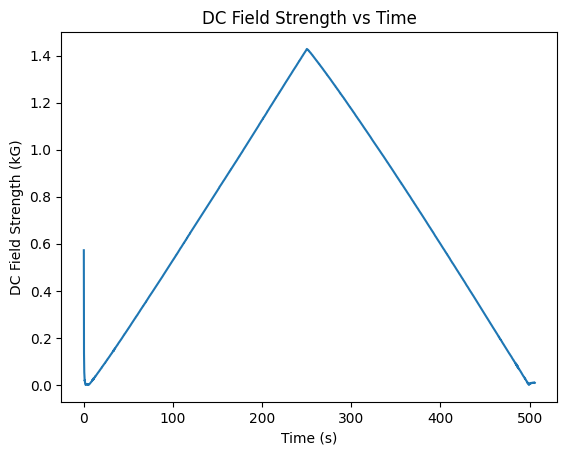

In [11]:
# Plot kGauss vs Time Graph

fig = plt.figure()  # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, kGauss)
plt.xlabel("Time (s)")
plt.ylabel("DC Field Strength (kG)")
plt.title("DC Field Strength vs Time")

fig.savefig(f"{metal}_{temp}_dc_sweep.pdf", dpi=300, bbox_inches="tight")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

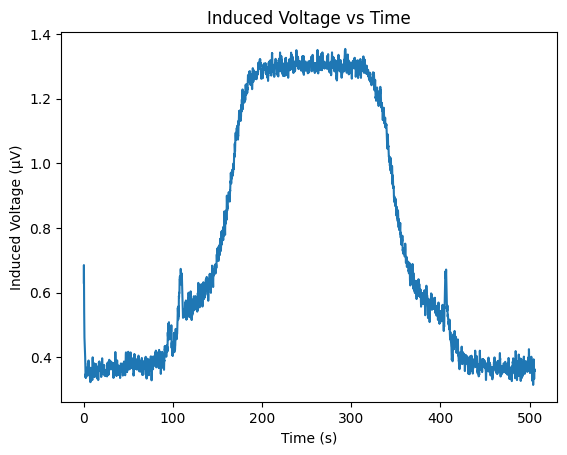

In [12]:
# Plot Induced Voltage vs Time Graph

fig = plt.figure() # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Induced Voltage (\u03bcV)")
plt.title("Induced Voltage vs Time")

fig.savefig(f"{metal}_{temp}_induced_voltage.pdf", dpi=300, bbox_inches="tight")

plt.show

**Split data for voltage vs field graphs**

We will split our data into the upward sweep and the downward sweep when graphing and analyzing our induced voltage as a function of DC magentic field

This is done to account for hysteresis in the measuring instruments and produce a more accurate critical field

In [13]:
# Index where the field amplitude begins decreasing
max_field_idx = kGauss.idxmax() 


# Split data into increasing and decreasing part of sweeps
up_sweep = df.iloc[:max_field_idx + 1] # .iloc keeps the rows in our .txt file from the 0 index to the max_field_idx index
down_sweep = df.iloc[max_field_idx:]# .iloc keeps the rows in our .txt file from the max_field_idx index to our last index

# These both contain the row at the max_field_idx for an overlap of 1

# Separate kGauss data for our upward sweep and our downward sweep 
kGauss_up = up_sweep["Channel_1(V)"].abs()
kGauss_down = down_sweep["Channel_1(V)"].abs()

# Separate voltage data for our upward sweep and our downward sweep
voltage_up = up_sweep["Channel_2(V)"]
voltage_down = down_sweep["Channel_2(V)"]

''' 
#Separate time data for our upward sweep and our downward sweep 
t_up = up_sweep["Time(s)"]
t_down = down_sweep["Time(s)"]
'''

' \n#Separate time data for our upward sweep and our downward sweep \nt_up = up_sweep["Time(s)"]\nt_down = down_sweep["Time(s)"]\n'

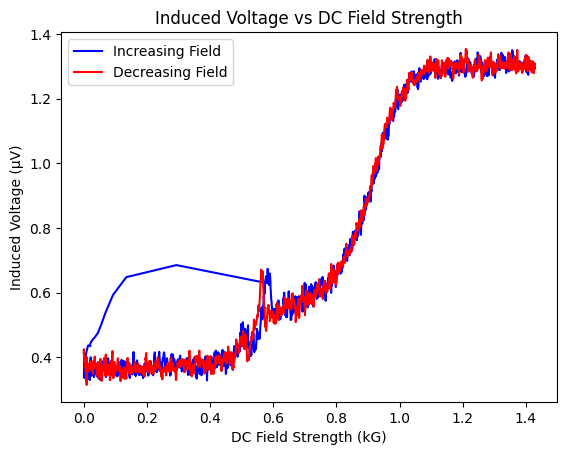

In [14]:
# Graph Induced Voltage vs kGauss


fig = plt.figure()  # Could replace this with plt.subplot(), depending on vibes
plt.plot(kGauss_up, voltage_up, label='Increasing Field', color='blue',) # Upward sweep is blue
plt.plot(kGauss_down, voltage_down, label='Decreasing Field', color='red') # Downward sweep is red
plt.xlabel("DC Field Strength (kG)")
plt.ylabel("Induced Voltage (\u03bcV)")
plt.title("Induced Voltage vs DC Field Strength")

plt.legend()

fig.savefig(f"{metal}_{temp}_voltage_field.pdf", dpi=300, bbox_inches="tight")

plt.show()